# Q3. Feature Engineering and Regression Pipeline
**Dataset:** q3_retail_promotions.csv | **Target:** items_sold

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')
print('Shape:', df.shape)
display(df.head())
print(df.dtypes)

Shape: (1200, 9)


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object


## 1. Date Feature Engineering

In [9]:
# Parse transaction_date and extract temporal features
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print('New columns added: year, month, day_of_week, is_month_end')
print('\nSample of new features:')
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(50)

New columns added: year, month, day_of_week, is_month_end

Sample of new features:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


## 2. Temporal Train-Test Split

In [10]:
# Sort by date and use most recent 20% as test set
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

print(f'Train size: {len(train_df)} | Date range: {train_df["transaction_date"].min().date()} to {train_df["transaction_date"].max().date()}')
print(f'Test  size: {len(test_df)}  | Date range: {test_df["transaction_date"].min().date()} to {test_df["transaction_date"].max().date()}')

Train size: 960 | Date range: 2022-01-01 to 2024-06-11
Test  size: 240  | Date range: 2024-06-12 to 2024-12-31


**Why random split is inappropriate for time-ordered data:**
A random split would allow the model to train on future data and test on past data (data leakage). In real-world deployments, a model only ever sees past data when predicting the future. A temporal split preserves this causal order — training on older records and testing on the most recent 20% — accurately simulating how the model would perform in production.

## 3. Preprocessing Pipeline

In [11]:
# Define feature sets
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['year', 'month', 'day_of_week', 'is_month_end',
                 'is_weekend', 'is_festival', 'competition_density']

target = 'items_sold'
drop_cols = ['transaction_date', 'store_id', target]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]
X_test  = test_df.drop(columns=drop_cols)
y_test  = test_df[target]

# Build ColumnTransformer
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features),
    ('scale',  StandardScaler(), num_features)
])

print('Preprocessing pipeline defined.')
print('Categorical (OHE):', cat_features)
print('Numerical (Scaled):', num_features)

Preprocessing pipeline defined.
Categorical (OHE): ['promotion_type', 'location_type', 'store_size']
Numerical (Scaled): ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']


## 4. Model Training and Evaluation

In [12]:
# Build pipelines for both models
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Fit ONLY on training set
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Evaluate on test set
for name, pipe in [('Linear Regression', lr_pipeline), ('Random Forest Regressor', rf_pipeline)]:
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f'{name} — RMSE: {rmse:.2f} | MAE: {mae:.2f}')

Linear Regression — RMSE: 27.26 | MAE: 21.10
Random Forest Regressor — RMSE: 31.19 | MAE: 25.03


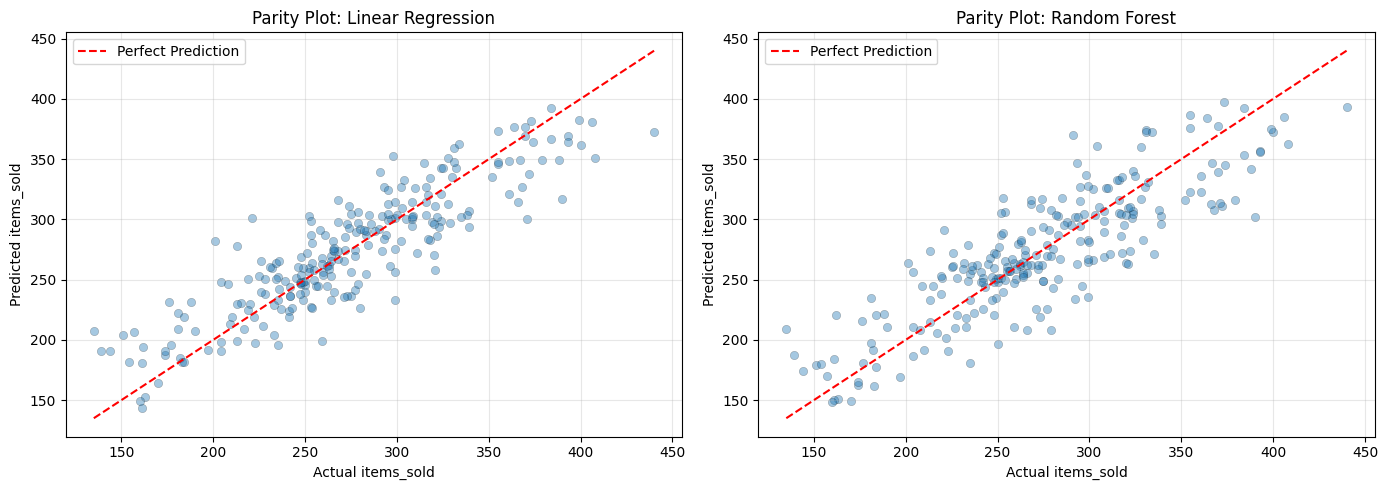

In [13]:
# Parity plots: predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, pipe) in zip(axes, [('Linear Regression', lr_pipeline), ('Random Forest', rf_pipeline)]):
    y_pred = pipe.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')
    ax.set_title(f'Parity Plot: {name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Top 5 Most Influential Features:
            Feature  Importance
        is_festival    0.173610
   store_size_small    0.165463
location_type_urban    0.107645
        day_of_week    0.085597
         is_weekend    0.069095


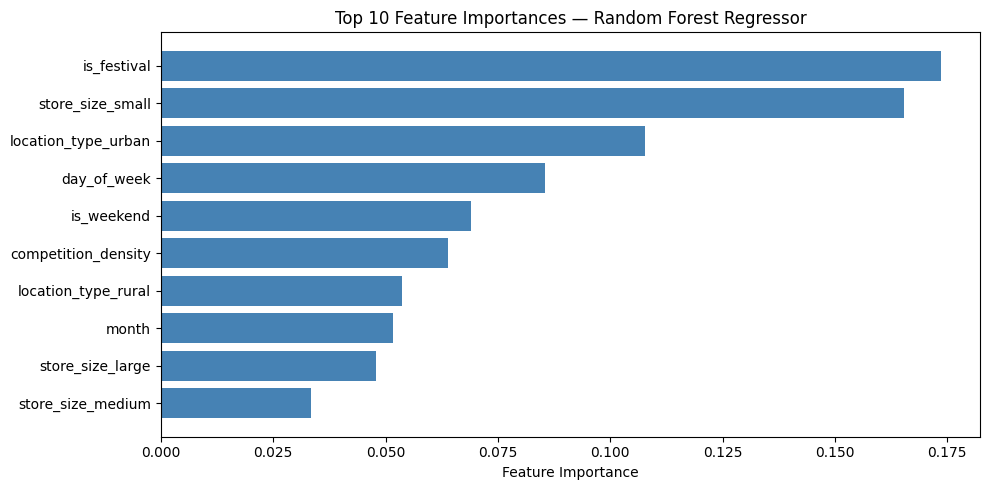

In [14]:
# Feature importances from Random Forest
rf_model = rf_pipeline.named_steps['model']
ohe_features = rf_pipeline.named_steps['preprocessor'].named_transformers_['onehot'].get_feature_names_out(cat_features)
all_features = list(ohe_features) + num_features

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 5 Most Influential Features:')
print(importance_df.head(5).to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'].head(10)[::-1], importance_df['Importance'].head(10)[::-1], color='steelblue')
plt.xlabel('Feature Importance')
plt.title('Top 10 Feature Importances — Random Forest Regressor')
plt.tight_layout()
plt.show()